## **Лабораторная работа "Прогнозирование (ARIMA)"**

**Задача:** Построить прогноз на 8 месяцев с применением метода ARIMA.

**Общее описание данных:**

Гостиницы Чикаго.
В таблицах представлена статистика коэффициента загрузки гостиниц и средней цены по двум районам Чикаго: Chicago Central Business District Hotel Statistics и Chicago Metropolitan Area Hotel Statistics.
Данные собирались ежемесячно с января 1994 по апрель 2003.

**Вариант 2:** Средняя цена номера в отеле в долларах (Average Daily Rate (in $)). Данные для Chicago Central Business District Hotel Statistics. Предоставлены средние значения цены за один день. Усреднение по отелям и по дням месяца.

Данные расположены в столбце x2 файла Chicago_hotels.csv

In [ ]:
# Импортируем необходимые для работы бибилиотеки
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.style.use('ggplot')
%matplotlib inline
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import adfuller
from pandas import DataFrame
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
# Загружаем данные
!gdown 1e86IS7-UQY2FXwvjDFBK5UH1989vJKcz

In [ ]:
df = pd.read_csv('Chicago_hotels.csv', sep=';', decimal=',', na_values = " ")
df.head()

,date1,date2,x1,x2,x3,x4
0,January,1994,44.3,104.04,51.9,72.15
1,February,1994,54.7,102.74,60.1,73.47
2,March,1994,61.9,105.23,65.0,74.91
3,April,1994,69.1,113.63,69.8,79.06
4,May,1994,70.8,120.77,72.4,82.07


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date1   120 non-null    object 
 1   date2   120 non-null    int64  
 2   x1      112 non-null    float64
 3   x2      112 non-null    float64
 4   x3      112 non-null    float64
 5   x4      112 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 5.8+ KB


In [ ]:
df.tail(10)

,date1,date2,x1,x2,x3,x4
110,March,2003,65.0,147.32,55.9,99.62
111,April,2003,69.0,150.72,58.4,101.32
112,May,2003,NaN,NaN,NaN,NaN
113,June,2003,NaN,NaN,NaN,NaN
114,July,2003,NaN,NaN,NaN,NaN
115,August,2003,NaN,NaN,NaN,NaN
116,September,2003,NaN,NaN,NaN,NaN
117,October,2003,NaN,NaN,NaN,NaN
118,November,2003,NaN,NaN,NaN,NaN
119,December,2003,NaN,NaN,NaN,NaN


Замечаем, что есть пропуски в данных, это месяцы, которые мы будем прогнозировать. Для построения модели будем использовать только наблюдаемую часть ряда без пропусков.

In [ ]:
data = df.iloc[:112]
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 112 entries, 1994-01-01 to 2003-04-01
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date1   112 non-null    object 
 1   date2   112 non-null    int64  
 2   x1      112 non-null    float64
 3   x2      112 non-null    float64
 4   x3      112 non-null    float64
 5   x4      112 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 6.1+ KB


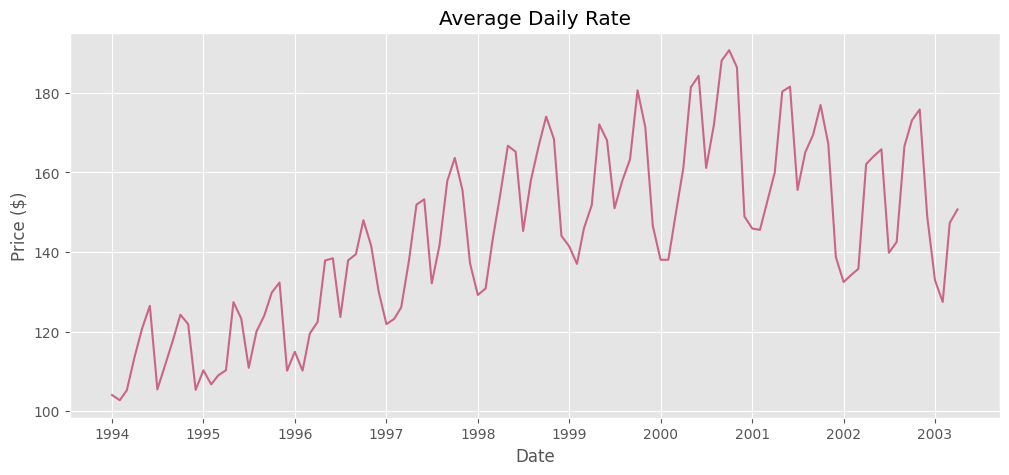

In [ ]:
df['date'] = pd.to_datetime(df['date1'] + ' ' + df['date2'].astype(str), format='%B %Y')

# делаем дату индексом
df.set_index('date', inplace=True)

# берем нужный ряд
y = data['x2']

plt.figure(figsize=(12,5))
plt.plot(y, color = '#CB6586')
plt.title('Average Daily Rate')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.show()

По графику временного ряда наблюдается восходящий тренд (до 2001) и годовая сезонность. Амплитуда сезонных колебаний увеличивается со временем. Так как есть сезонность, то будем использовать модель SARIMA.

Временной ряд скорее всего является нестационарным. Проверим стационарность ряда с помощью теста Дики-Фуллера.

In [ ]:
result = adfuller(y)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

if result[1] <= 0.05:
  print('Ряд стационарен')
else:
  print('Ряд нестационарен')

ADF Statistic: -1.86464594504685
p-value: 0.348871092179599
Ряд нестационарен


Построим графики ACF и PACF для подбора параметров модели.

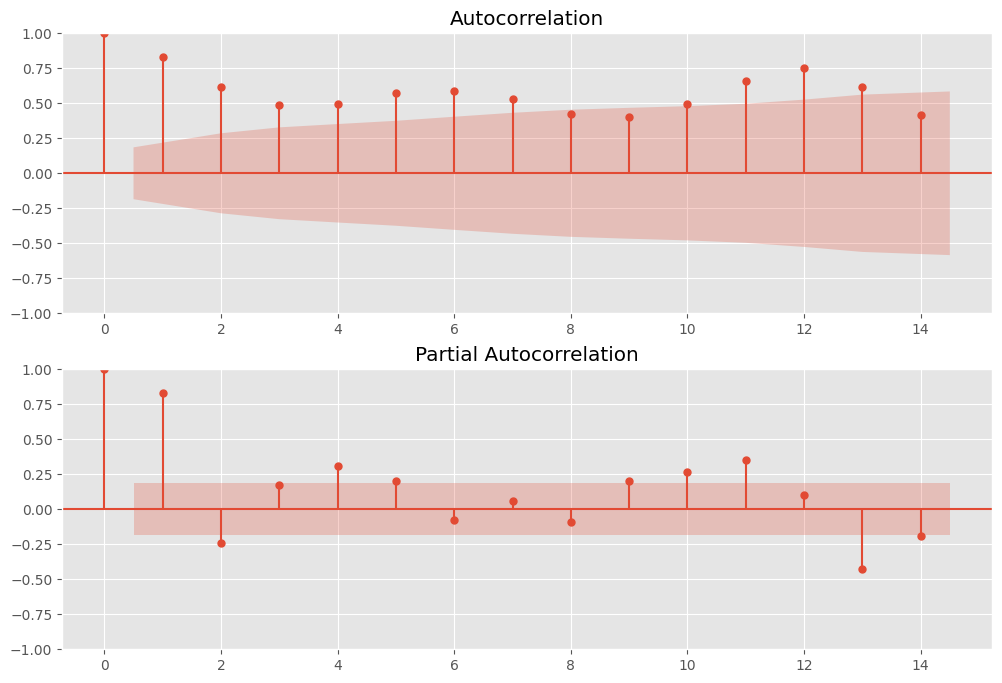

In [ ]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(y, lags=14, ax=plt.gca())
plt.subplot(212)

plot_pacf(y, method='ywmle', lags=14, ax=plt.gca())
plt.show()

Поскольку ряд нестационарен, необходимо взять первую разность и сезонное дифференцирование.

In [ ]:
# обучающая часть
y_train = y.dropna()

# первая разность
y_diff = y_train.diff()

# сезонная разность
y_season_diff = y_diff.diff(12)

# удаляем NaN
y_season_diff = y_season_diff.dropna()

In [ ]:
result = adfuller(y_season_diff)

print('ADF Statistic:', result[0])
print('p-value:', result[1])

if result[1] <= 0.05:
    print('Ряд стационарен')
else:
    print('Ряд нестационарен')

ADF Statistic: -2.6998177386405993
p-value: 0.07406981352526737
Ряд нестационарен


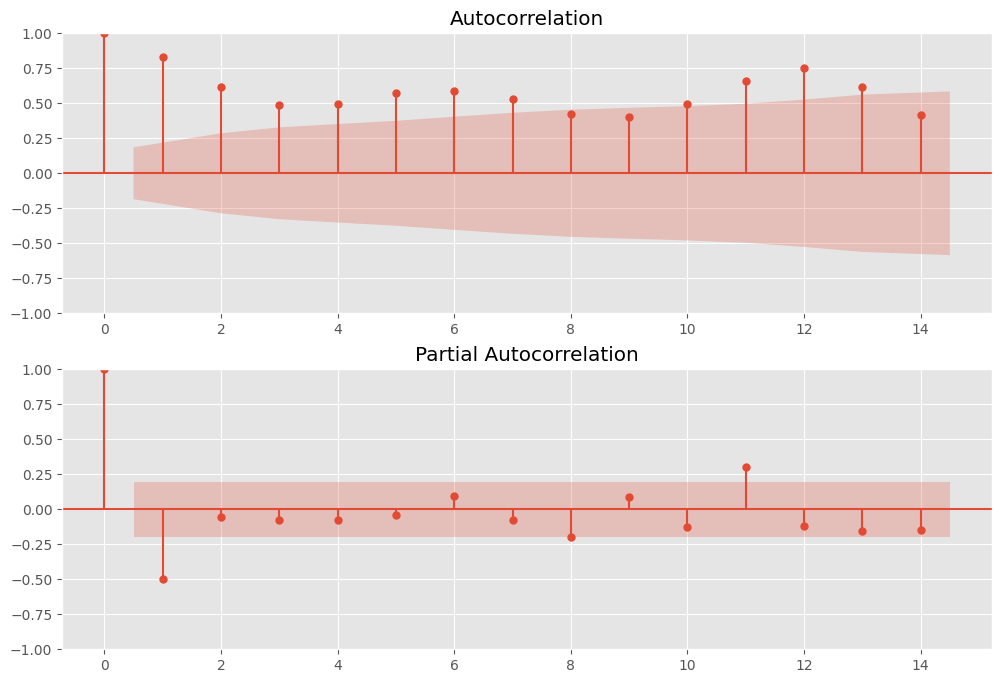

In [ ]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(y, lags=14, ax=plt.gca())
plt.subplot(212)

plot_pacf(y_season_diff, method='ywmle', lags=14, ax=plt.gca())
plt.show()

По графику видно, что:

*   ACF убывает медленно и не обрывается резко, это является признаком нестационарного ряда -> d = 1;
*  Выраженная годовая сезонность -> сезонное дифференцирование D = 1, период s = 12;
*  значимые значения ACF на малых лагах -> наличие MA-компоненты;
*   PACF показывает значимый пик на лаге 1, а также в области сезонного лага -> наличие AR-компоненты.

Попробуем следующие модели SARIMA: SARIMA(1,1,1)(1,1,1,12), SARIMA(1,1,0)(1,1,0,12), SARIMA(0,1,1)(0,1,1,12)

In [ ]:
# модель SARIMA (1,1,1)(1,1,1,12)
model_1 = SARIMAX(y, order=(1,1,1), seasonal_order=(1,1,1,12))
model_fit_1 = model_1.fit()
print(model_fit_1.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                                 x2   No. Observations:                  112
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -311.813
Date:                            Mon, 11 May 2026   AIC                            633.626
Time:                                    18:12:19   BIC                            646.602
Sample:                                01-01-1994   HQIC                           638.876
                                     - 04-01-2003                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1906      0.216     -0.881      0.378      -0.614       0.233
ma.L1         -0.2879      0.208   

In [ ]:
# модель SARIMA (0,1,1)(0,1,1,12)
model_2 = SARIMAX(y, order=(0,1,1), seasonal_order=(0,1,1,12))
model_fit_2 = model_2.fit()
print(model_fit_2.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                                 x2   No. Observations:                  112
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -312.679
Date:                            Mon, 11 May 2026   AIC                            631.358
Time:                                    18:12:51   BIC                            639.144
Sample:                                01-01-1994   HQIC                           634.508
                                     - 04-01-2003                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4752      0.085     -5.621      0.000      -0.641      -0.310
ma.S.L12      -0.5292      0.102   

In [ ]:
# модель SARIMA (1,1,0)(1,1,0,12)
model_3 = SARIMAX(y, order=(1,1,0), seasonal_order=(1,1,0,12))
model_fit_3 = model_3.fit()
print(model_fit_3.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                 x2   No. Observations:                  112
Model:             SARIMAX(1, 1, 0)x(1, 1, 0, 12)   Log Likelihood                -313.264
Date:                            Mon, 11 May 2026   AIC                            632.529
Time:                                    18:13:40   BIC                            640.314
Sample:                                01-01-1994   HQIC                           635.679
                                     - 04-01-2003                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4667      0.081     -5.735      0.000      -0.626      -0.307
ar.S.L12      -0.4860      0.112   

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


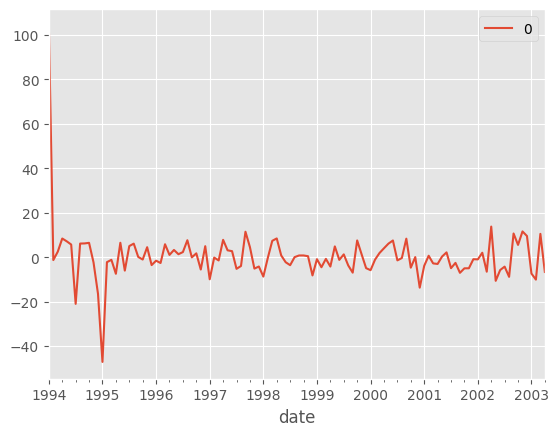

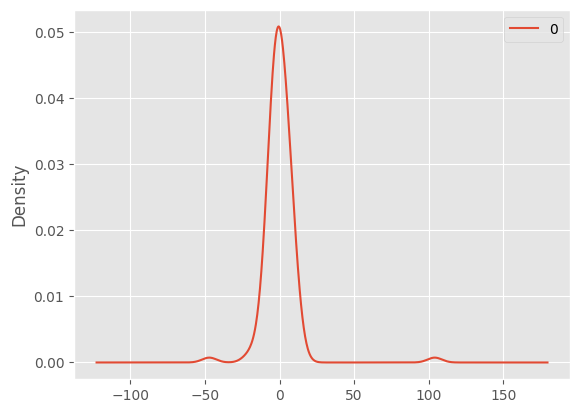

                0
count  112.000000
mean     0.273830
std     12.421228
min    -47.120259
25%     -4.312447
50%     -0.356674
75%      4.599529
max    104.040000


In [ ]:
# Анализ остатков SARIMA (1,1,1)(1,1,1,12)
residuals_1 = pd.DataFrame(model_fit_1.resid)
residuals_1.plot()
plt.show()

residuals_1.plot(kind='kde')
plt.show()
print(residuals_1.describe())

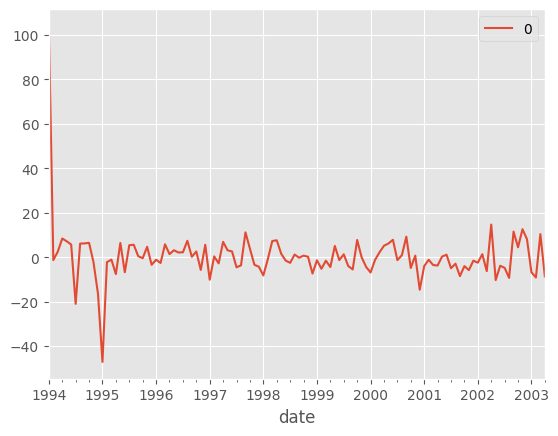

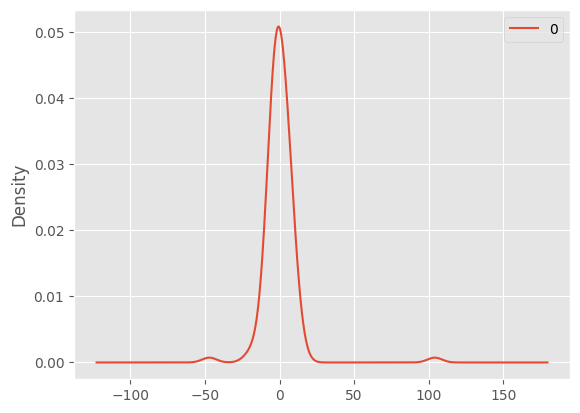

                0
count  112.000000
mean     0.253810
std     12.444552
min    -47.120469
25%     -4.089157
50%     -0.702175
75%      4.771929
max    104.040000


In [ ]:
# Анализ остатков SARIMA (0,1,1)(0,1,1,12)
residuals_2 = pd.DataFrame(model_fit_2.resid)
residuals_2.plot()
plt.show()

residuals_2.plot(kind='kde')
plt.show()
print(residuals_2.describe())

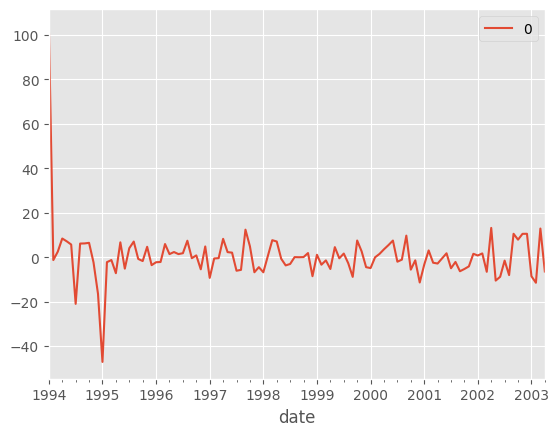

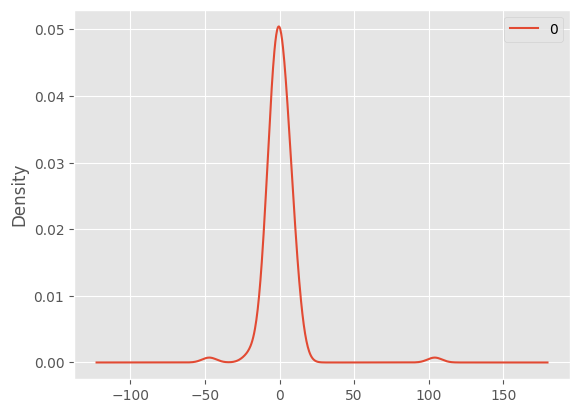

                0
count  112.000000
mean     0.326196
std     12.456787
min    -47.120298
25%     -4.490098
50%     -0.477360
75%      4.555581
max    104.040000


In [ ]:
# Анализ остатков SARIMA SARIMA (1,1,0)(1,1,0,12)
residuals_3 = pd.DataFrame(model_fit_3.resid)
residuals_3.plot()
plt.show()

residuals_3.plot(kind='kde')
plt.show()
print(residuals_3.describe())

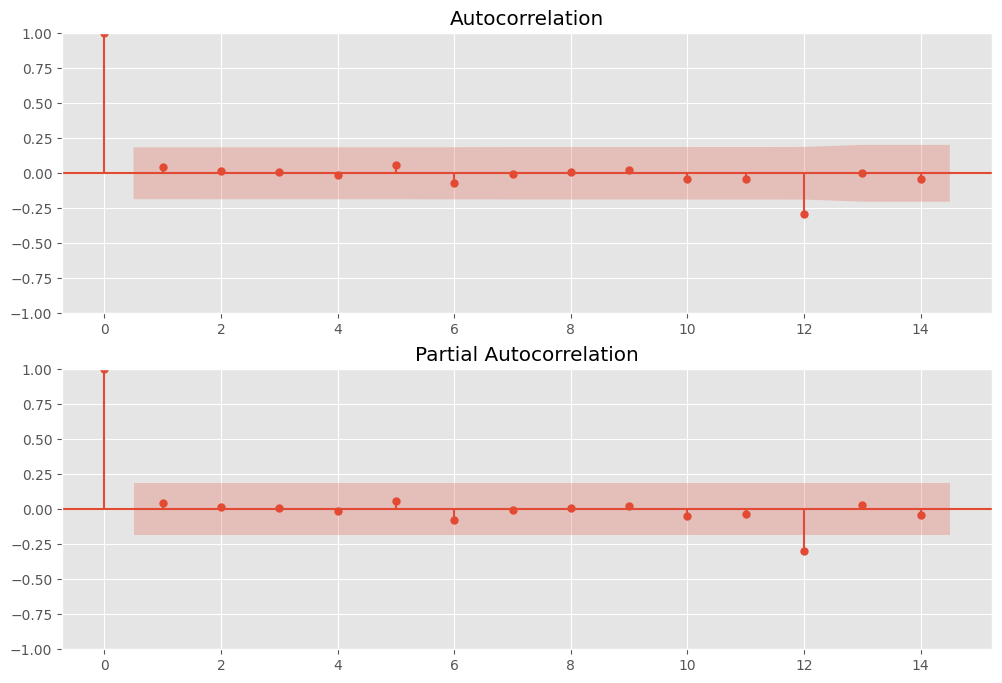

In [ ]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(residuals_1, lags=14, ax=plt.gca())
plt.subplot(212)

plot_pacf(residuals_1, method='ywmle', lags=14, ax=plt.gca())
plt.show()

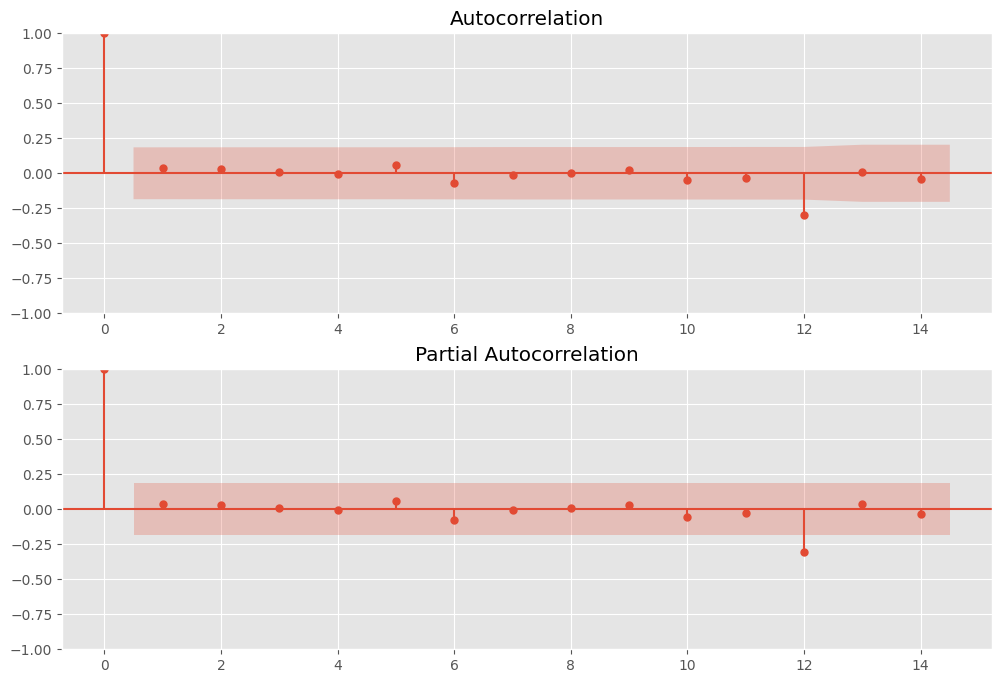

In [ ]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(residuals_2, lags=14, ax=plt.gca())
plt.subplot(212)

plot_pacf(residuals_2, method='ywmle', lags=14, ax=plt.gca())
plt.show()

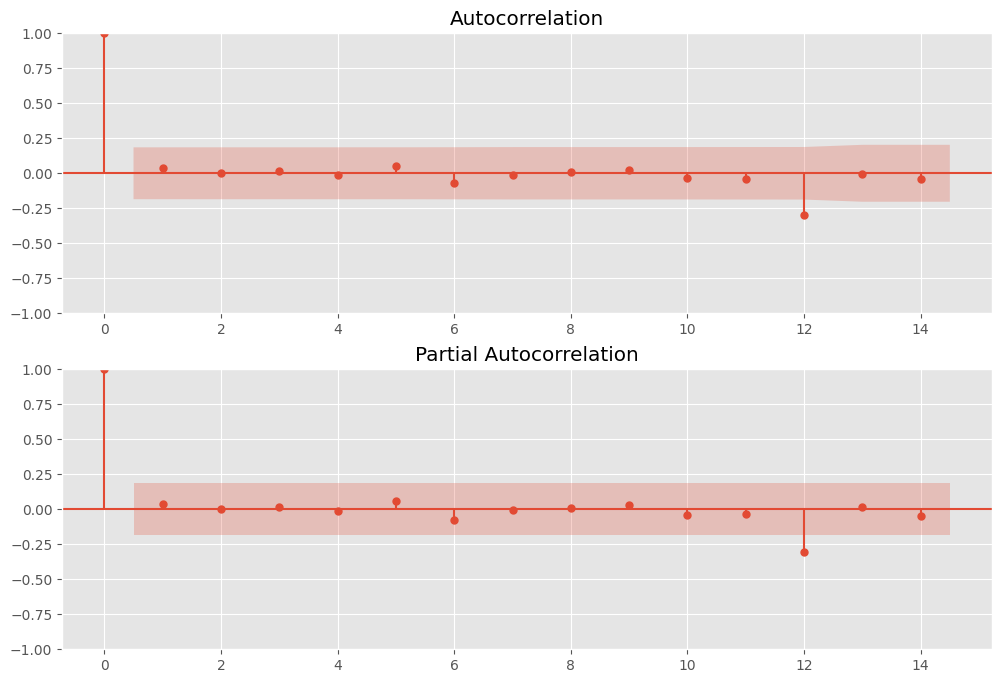

In [ ]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(residuals_3, lags=14, ax=plt.gca())
plt.subplot(212)

plot_pacf(residuals_3, method='ywmle', lags=14, ax=plt.gca())
plt.show()

In [ ]:
# Сравнение моделей по AIC и BIC
comparison = pd.DataFrame({
    'Model': ['SARIMA (1,1,1)(1,1,1,12)', 'SARIMA (0,1,1)(0,1,1,12)', 'SARIMA (1,1,0)(1,1,0,12)'],
    'AIC': [model_fit_1.aic, model_fit_2.aic, model_fit_3.aic],
    'BIC': [model_fit_1.bic, model_fit_2.bic, model_fit_3.bic]})

comparison = comparison.sort_values('AIC')
print(comparison)

                      Model         AIC         BIC
1  SARIMA (0,1,1)(0,1,1,12)  631.358265  639.143624
2  SARIMA (1,1,0)(1,1,0,12)  632.528626  640.313986
0  SARIMA (1,1,1)(1,1,1,12)  633.626180  646.601779


По результатам сравнения моделей выбираем SARIMA(0,1,1)(0,1,1,12):

- Наименьшии значения AIC и BIC;
- Остатки во всех моделях ведут себя одинаково — ACF/PACF остатков не выявили структуры;
- Все компоненты статистически значимы;
- Является наиболее простой моделью.

In [ ]:
model = SARIMAX(y.dropna(), order=(0,1,1), seasonal_order=(0,1,1,12))
model_fit = model.fit()

forecast_obj = model_fit.get_forecast(steps=8)

forecast_mean = forecast_obj.predicted_mean
forecast_ci = forecast_obj.conf_int()

print(forecast_mean)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


2003-05-01    165.949765
2003-06-01    167.160145
2003-07-01    142.714431
2003-08-01    149.160944
2003-09-01    164.794537
2003-10-01    171.826824
2003-11-01    169.023768
2003-12-01    141.029061
Freq: MS, Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


MAE: 16.000
MAPE: 10.49%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


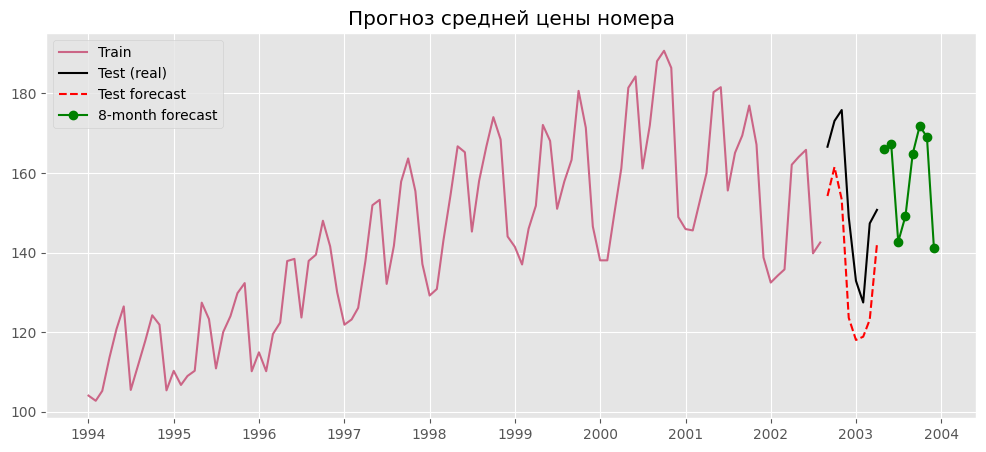

In [ ]:
train = y[:-8]
test = y[-8:]

# Обучение модели на train
model = SARIMAX(train, order=(0,1,1), seasonal_order=(0,1,1,12))
model_fit = model.fit()

test_pred_obj = model_fit.get_forecast(steps=8)
test_pred = test_pred_obj.predicted_mean

mae = mean_absolute_error(test, test_pred)
mape = mean_absolute_percentage_error(test, test_pred)

print(f"MAE: {mae:.3f}")
print(f"MAPE: {mape:.2%}")

final_model = SARIMAX(y, order=(0,1,1), seasonal_order=(0,1,1,12))
final_fit = final_model.fit()

# прогноз на 8 месяцев вперёд
forecast_obj = final_fit.get_forecast(steps=8)
forecast_mean = forecast_obj.predicted_mean
forecast_ci = forecast_obj.conf_int()

plt.figure(figsize=(12,5))
plt.plot(train.index, train, label='Train', color='#CB6586')
plt.plot(test.index, test, label='Test (real)', color='black')
plt.plot(test.index, test_pred, '--', label='Test forecast', color='red')
plt.plot(forecast_mean.index, forecast_mean,
         'o-', label='8-month forecast', color='green')

plt.title('Прогноз средней цены номера')
plt.legend()
plt.show()

По результатам прогнозирования средней цены номера в отеле с использованием модели SARIMA(0,1,1)(0,1,1,12) получены значения метрик качества MAE = 16.00 и MAPE = 10.49%, что свидетельствует о хорошей точности модели и приемлемом уровне ошибки для экономического временного ряда с выраженной сезонностью.

Полученный прогноз корректно отражает общую динамику и сезонные колебания ряда, однако по сравнению с методом сезонной декомпозиции и методом экспоненциального сглаживания имеет более высокую ошибку, что объясняется стохастической природой SARIMA-модели, учитывающей случайную составляющую временного ряда и дающей более реалистичную оценку неопределённости.